# Assignment 9

Autoencoders and Variational Autoencoders


## Imports


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import math


## Task 1 — Linear autoencoder and PCA on 3D data (3 pts)

In this task, you will train a very small autoencoder with architecture:
3→2→3

The goal is to compress 3-dimensional data into a 2-dimensional latent representation and reconstruct the original input.

A linear autoencoder trained with mean squared error learns a low-dimensional subspace similar to PCA. The exact coordinates in the latent space may be different, but the reconstruction quality and the learned subspace should be comparable.

### Dataset

Generate a simple 3D dataset with strong correlation between coordinates.

Each sample has shape: x ∈ R³

The latent representation has shape: z ∈ R²

### Requirements

1. Create a linear autoencoder: encoder: Linear(3, 2), decoder: Linear(2, 3). Do not use nonlinear activations in this task.
2. Train the autoencoder using: MSELoss, an optimizer from torch.optim, at least 500 training steps.
3. Plot: training loss vs iteration, original 3D points, reconstructed 3D points, 2D latent codes produced by the encoder.
4. Fit PCA with 2 components to the same centered data.
5. Compare: reconstruction MSE of the autoencoder, reconstruction MSE of PCA.
6. Print a small table:

| Method | Latent dimension | Reconstruction MSE |
|--------|-----------------|-------------------|
| Linear AE | 2 | ... |
| PCA | 2 | ... |

### Required discussion

Explain:
- what the encoder learns,
- what the decoder learns,
- why the bottleneck forces compression,
- why the result should be similar to PCA,
- why the latent coordinates of the autoencoder do not have to be identical to PCA coordinates,
- whether the autoencoder and PCA reached similar reconstruction errors.


### Solution


In [2]:
torch.manual_seed(42)

n = 1000

u = torch.randn(n, 1)
v = torch.randn(n, 1)

x1 = u
x2 = 0.5 * u + v
x3 = 2.0 * u - 0.3 * v + 0.1 * torch.randn(n, 1)

X = torch.cat([x1, x2, x3], dim=1)

X = X - X.mean(dim=0, keepdim=True)


In [3]:
class LinearAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(3, 2)
        self.decoder = nn.Linear(2, 3)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


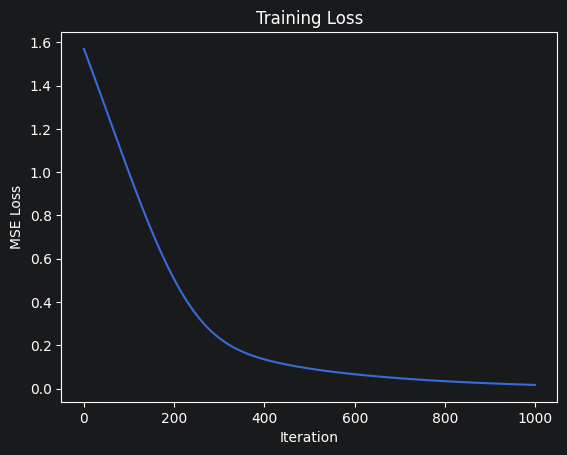

In [4]:
model = LinearAutoencoder()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses = []
for step in range(1000):
    optimizer.zero_grad()
    x_hat, z = model(X)
    loss = criterion(x_hat, X)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()


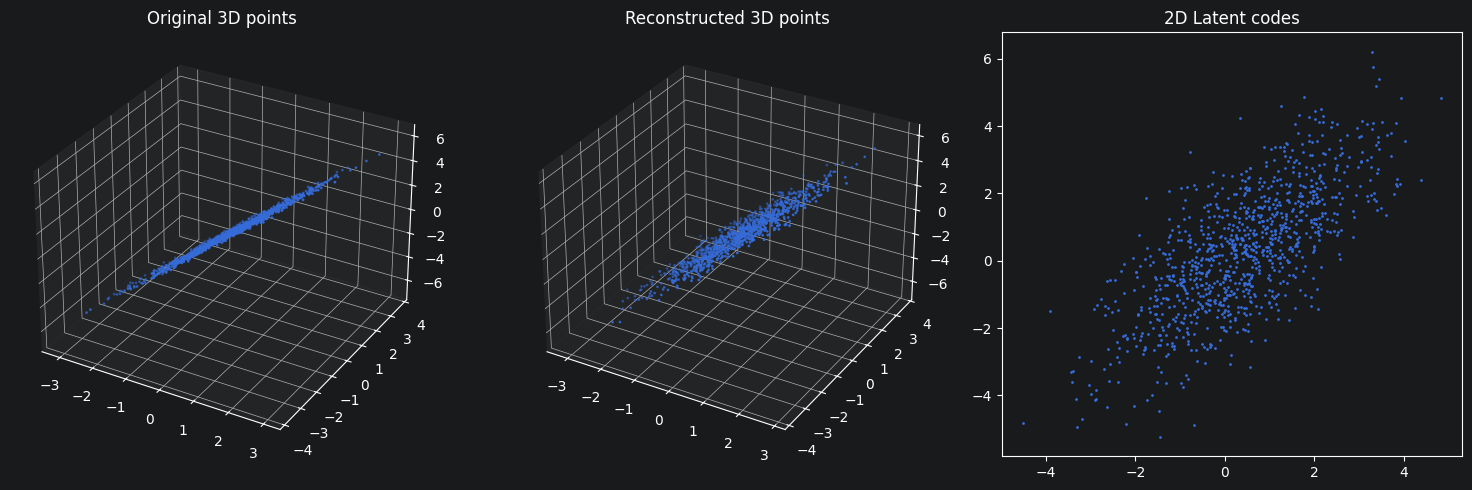

In [5]:
with torch.no_grad():
    x_hat, z = model(X)

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], s=1)
ax1.set_title("Original 3D points")

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(x_hat[:, 0], x_hat[:, 1], x_hat[:, 2], s=1)
ax2.set_title("Reconstructed 3D points")

ax3 = fig.add_subplot(133)
ax3.scatter(z[:, 0], z[:, 1], s=1)
ax3.set_title("2D Latent codes")

plt.tight_layout()
plt.show()


In [6]:
pca = PCA(n_components=2)
X_np = X.numpy()
Z_pca = pca.fit_transform(X_np)
X_pca_reconstructed = pca.inverse_transform(Z_pca)

mse_ae = criterion(x_hat, X).item()
mse_pca = np.mean((X_np - X_pca_reconstructed) ** 2)

df = pd.DataFrame({
    "Method": ["Linear AE", "PCA"],
    "Latent dimension": [2, 2],
    "Reconstruction MSE": [mse_ae, mse_pca]
})
df


,Method,Latent dimension,Reconstruction MSE
0,Linear AE,2,0.016581
1,PCA,2,0.000579


### Discussion

- **What the encoder learns:** The encoder learns a linear projection from 3D to 2D that captures the directions of maximum variance in the data.

- **What the decoder learns:** The decoder learns the inverse mapping that reconstructs the original 3D points from the 2D latent codes.

- **Why the bottleneck forces compression:** The 2-dimensional bottleneck forces the network to discard the least informative direction and retain only the two most important axes of variation.

- **Why the result should be similar to PCA:** A linear autoencoder minimizing MSE converges to the same subspace spanned by the top principal components, since both methods find the rank-k subspace that minimizes reconstruction error.

- **Why the latent coordinates of the autoencoder do not have to be identical to PCA coordinates:** Any rotation or scaling of the latent space still spans the same subspace, so the autoencoder can find an equivalent but differently oriented basis.

- **Whether the autoencoder and PCA reached similar reconstruction errors:** Yes, both methods should achieve nearly identical reconstruction MSE since they recover the same optimal 2D subspace.



## Task 2 — Denoising autoencoder on Fashion-MNIST (3 pts)

In this task, you will train a convolutional autoencoder that receives a noisy image and tries to reconstruct the clean image.

The model learns: noisy image → encoder → z → decoder → clean image

This is called a denoising autoencoder.

### Dataset

Use Fashion-MNIST. Each image has shape: x ∈ R^(1×28×28). Use pixel values in the range [0,1].

To create noisy images, add Gaussian noise: x̃ = x + σε, ε ~ N(0,I)

Then clamp the result to [0,1]: x̃ = clamp(x̃, 0, 1)

Suggested noise level: σ = 0.3

### Requirements

1. Load Fashion-MNIST using TorchVision.
2. Create a function add_noise(x, noise_std) that adds Gaussian noise and clamps the result.
3. Implement a convolutional autoencoder.
4. Train the model for at least 5 epochs.
5. Use: noisy image as input, clean image as target, MSELoss.
6. Track and plot training loss.
7. Show at least 8 examples with three rows: clean image, noisy image, reconstructed / denoised image.
8. Try at least two noise levels, for example: σ=0.1, σ=0.3, optionally σ=0.5.
9. Briefly compare the quality of denoising for different noise levels.

### Required discussion

Explain:
- why this is still an autoencoder,
- why the input and target are different,
- what the latent representation contains,
- why very large noise makes the task harder,
- whether the model removes noise or also blurs some details.


### Solution


In [7]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 26.4M/26.4M [00:00<00:00, 49.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 824kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 15.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.9MB/s]


In [8]:
def add_noise(x, noise_std=0.3):
    noise = torch.randn_like(x) * noise_std
    x_noisy = x + noise
    x_noisy = torch.clamp(x_noisy, 0.0, 1.0)
    return x_noisy


In [9]:
class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device, noise_std):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_std=noise_std)

        optimizer.zero_grad()
        reconstructed = model(noisy)
        loss = criterion(reconstructed, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clean.size(0)
        total_samples += clean.size(0)

    return total_loss / total_samples


Epoch 1/10, Loss: 0.030878
Epoch 2/10, Loss: 0.012845
Epoch 3/10, Loss: 0.012001
Epoch 4/10, Loss: 0.011527
Epoch 5/10, Loss: 0.011176
Epoch 6/10, Loss: 0.010994
Epoch 7/10, Loss: 0.010855
Epoch 8/10, Loss: 0.010753
Epoch 9/10, Loss: 0.010659
Epoch 10/10, Loss: 0.010599


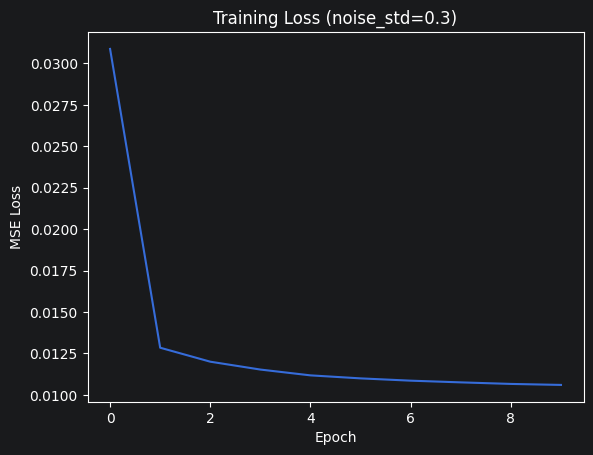

In [11]:
noise_std = 0.3
model = ConvDenoisingAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 10
train_losses = []

for epoch in range(epochs):
    loss = train_one_epoch(model, train_loader, optimizer, criterion, device, noise_std)
    train_losses.append(loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.6f}")

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Training Loss (noise_std={noise_std})")
plt.show()


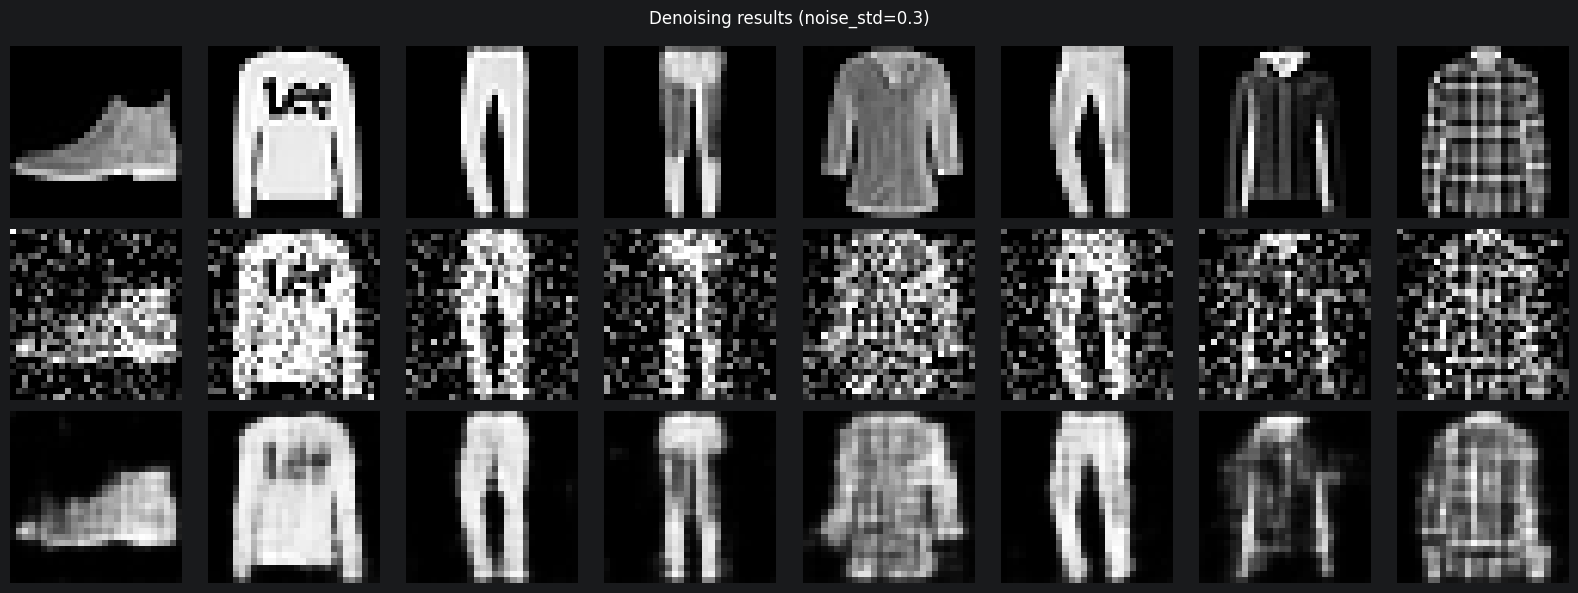

In [12]:
def show_denoising_results(model, test_loader, device, noise_std, n=8):
    model.eval()
    clean_imgs, _, = next(iter(test_loader))
    clean_imgs = clean_imgs[:n].to(device)
    noisy_imgs = add_noise(clean_imgs, noise_std=noise_std)

    with torch.no_grad():
        reconstructed = model(noisy_imgs)

    clean_imgs = clean_imgs.cpu()
    noisy_imgs = noisy_imgs.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))
    for i in range(n):
        axes[0, i].imshow(clean_imgs[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(reconstructed[i].squeeze(), cmap="gray")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Clean")
    axes[1, 0].set_ylabel("Noisy")
    axes[2, 0].set_ylabel("Denoised")
    plt.suptitle(f"Denoising results (noise_std={noise_std})")
    plt.tight_layout()
    plt.show()

show_denoising_results(model, test_loader, device, noise_std)


### Comparison of noise levels


Training with noise_std=0.1
  Final loss: 0.003266


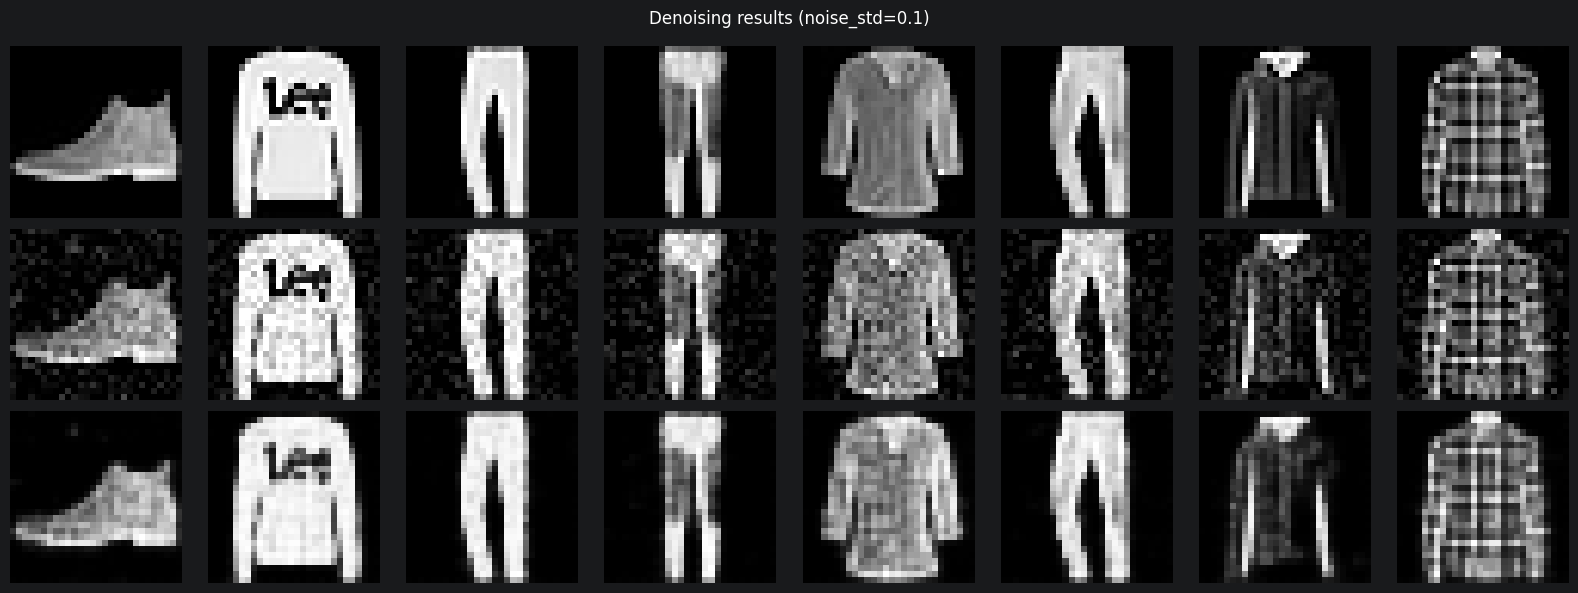

Training with noise_std=0.3
  Final loss: 0.010478


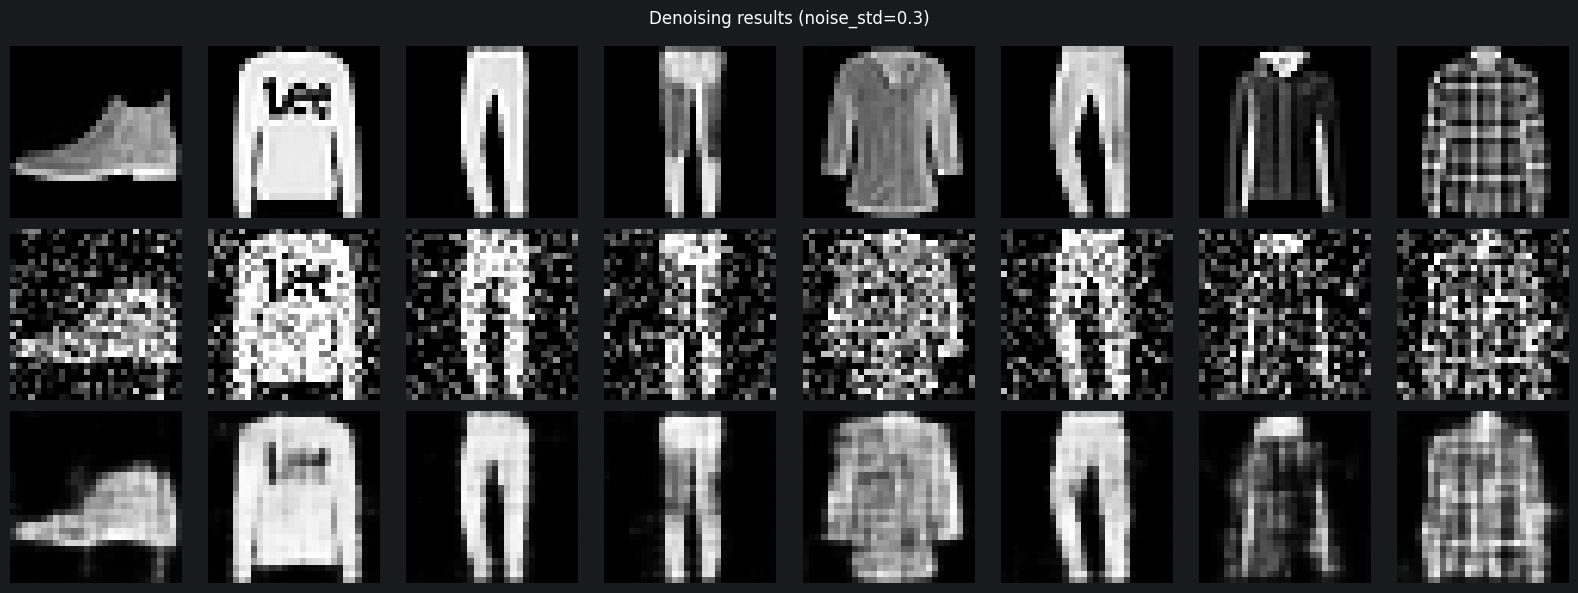

Training with noise_std=0.5
  Final loss: 0.018358


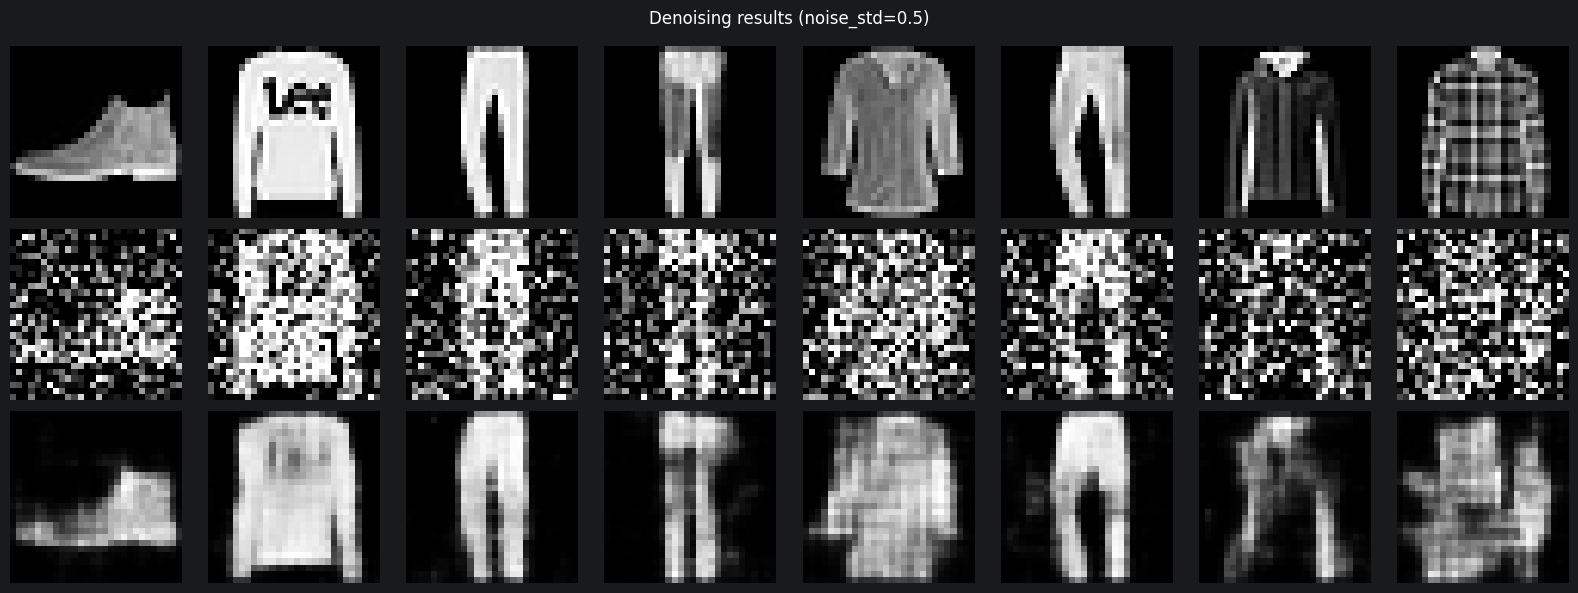

In [13]:
# Train and compare with different noise levels
noise_levels = [0.1, 0.3, 0.5]

for ns in noise_levels:
    print(f"Training with noise_std={ns}")
    model_ns = ConvDenoisingAE().to(device)
    optimizer_ns = optim.Adam(model_ns.parameters(), lr=1e-3)

    for epoch in range(10):
        loss = train_one_epoch(model_ns, train_loader, optimizer_ns, criterion, device, ns)

    print(f"  Final loss: {loss:.6f}")
    show_denoising_results(model_ns, test_loader, device, ns)


### Discussion

- **Why this is still an autoencoder:** It still follows the encoder-decoder structure that compresses input into a latent representation and reconstructs an output from it.

- **Why the input and target are different:** The input is a corrupted (noisy) image while the target is the original clean image, so the model learns to remove noise rather than simply copy.

- **What the latent representation contains:** The latent space captures the essential structure and features of the clean image while discarding the noise.

- **Why very large noise makes the task harder:** With very large noise, the original signal is almost completely destroyed, leaving insufficient information for the encoder to recover meaningful features.

- **Whether the model removes noise or also blurs some details:** The model removes noise but also tends to blur fine details, since the MSE loss encourages averaging over uncertain pixel values.



## Task 3 — First steps toward Variational Autoencoders (3 pts)

In this task, you do not need to train a full VAE. The goal is to understand the mathematical and implementation components that appear in the VAE loss.

A VAE encoder does not output one deterministic vector z. Instead, it outputs parameters of a distribution:
q_φ(z|x) = N(μ_φ(x), diag(σ²_φ(x)))

Then we sample: z ~ q_φ(z|x) and decode z.

### Part A — KL divergence between two 1D normal distributions

For two one-dimensional Gaussian distributions,
q(z) = N(μ_q, σ²_q) and p(z) = N(μ_p, σ²_p),

the KL divergence is:
D_KL(q||p) = log(σ_p/σ_q) + (σ²_q + (μ_q - μ_p)²) / (2σ²_p) - 1/2

Calculate the following by hand or using Python:
1. q = N(0,1), p = N(0,1)
2. q = N(1,1), p = N(0,1)
3. q = N(0, 0.5²), p = N(0,1)
4. q = N(0, 2²), p = N(0,1)

Create a table with columns: μ_q, σ_q, μ_p, σ_p, D_KL(q||p)

### Part B — KL term used in a standard VAE

In the most common VAE implementation, the prior is: p(z) = N(0, I)
and the encoder gives a diagonal Gaussian: q_φ(z|x) = N(μ, diag(σ²))

The KL divergence is:
D_KL(q_φ(z|x) || p(z)) = 1/2 * Σ(σ²_j + μ²_j - 1 - log σ²_j)

In code, we often use logvar: logvar_j = log σ²_j

Then: D_KL = -1/2 * Σ(1 + logvar_j - μ²_j - exp(logvar_j))

### Part C — Reparameterization trick

The problem is that direct sampling z ~ N(μ, σ²) contains randomness. The reparameterization trick writes the same sample as:
z = μ + σ ⊙ ε, ε ~ N(0, I)

Requirements:
- Create tensors mu and logvar.
- Generate at least 10000 samples for a simple 1D case.
- Verify empirically that the sample mean is close to mu.
- Verify empirically that the sample standard deviation is close to sigma.
- Explain why this trick is useful for training neural networks with backpropagation.


### Part A — Solution


In [14]:
def kl_divergence_1d(mu_q, sigma_q, mu_p, sigma_p):
    return math.log(sigma_p / sigma_q) + (sigma_q**2 + (mu_q - mu_p)**2) / (2 * sigma_p**2) - 0.5

cases = [
    (0, 1, 0, 1),
    (1, 1, 0, 1),
    (0, 0.5, 0, 1),
    (0, 2, 0, 1),
]

rows = []
for mu_q, sigma_q, mu_p, sigma_p in cases:
    kl = kl_divergence_1d(mu_q, sigma_q, mu_p, sigma_p)
    rows.append({"mu_q": mu_q, "sigma_q": sigma_q, "mu_p": mu_p, "sigma_p": sigma_p, "D_KL(q||p)": kl})

df_kl = pd.DataFrame(rows)
df_kl


,mu_q,sigma_q,mu_p,sigma_p,D_KL(q||p)
0,0,1.0,0,1,0.000000
1,1,1.0,0,1,0.500000
2,0,0.5,0,1,0.318147
3,0,2.0,0,1,0.806853


### Part B — Solution


In [15]:
def kl_standard_normal(mu, logvar):
    """
    mu: tensor of shape (batch_size, latent_dim)
    logvar: tensor of shape (batch_size, latent_dim)
    returns: tensor of shape (batch_size,)
    """
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl

mu = torch.tensor([[0.0, 0.0],
                   [1.0, 0.0],
                   [0.0, 2.0]])

logvar = torch.tensor([[0.0, 0.0],
                       [0.0, 0.0],
                       [0.0, 0.0]])

kl_values = kl_standard_normal(mu, logvar)
print("KL divergence values:")
for i, kl in enumerate(kl_values):
    print(f"  Sample {i}: mu={mu[i].tolist()}, logvar={logvar[i].tolist()} -> KL = {kl.item():.6f}")


KL divergence values:
  Sample 0: mu=[0.0, 0.0], logvar=[0.0, 0.0] -> KL = -0.000000
  Sample 1: mu=[1.0, 0.0], logvar=[0.0, 0.0] -> KL = 0.500000
  Sample 2: mu=[0.0, 2.0], logvar=[0.0, 0.0] -> KL = 2.000000


### Part B — Explanation

The first sample (mu=[0,0]) has zero KL because it already matches the standard normal prior; the second sample (mu=[1,0]) has non-zero KL because shifting the mean away from zero increases divergence; the third sample (mu=[0,2]) has the largest KL because a large mean deviation in one dimension contributes significantly to the divergence.



### Part C — Solution


In [16]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z

torch.manual_seed(42)

mu_val = 3.0
sigma_val = 2.0
logvar_val = math.log(sigma_val**2)

mu_tensor = torch.full((10000, 1), mu_val)
logvar_tensor = torch.full((10000, 1), logvar_val)

samples = reparameterize(mu_tensor, logvar_tensor)

print(f"Expected mean: {mu_val}, Empirical mean: {samples.mean().item():.4f}")
print(f"Expected std: {sigma_val}, Empirical std: {samples.std().item():.4f}")


Expected mean: 3.0, Empirical mean: 3.0129
Expected std: 2.0, Empirical std: 2.0089


### Part C — Discussion

The reparameterization trick moves the stochasticity out of the computational graph into a fixed noise input, allowing gradients to flow through mu and logvar during backpropagation.

